## A ~8M MoE transformer trained on 3-digit addition, written in JAX¶


Hyperparams

* `n_layers` = 12
*  `d_model` = 256
*  `d_ff` = 512
*  `n_heads` = 16
*  `n_kv_heads` = 2
*  `d_qkv` = 16
*  `n_embed` = 13
*  `n_experts` = 8
*  `n_active` = 2

Total params: $2D(N+K)HL + 2DEFL + 2DV + DEL = 2.70e7$ (~27M)

Active params: $2D(N+K)HL + 2DkFL + 2DV + DEL = 8.09e6$ (~8M), where $k$ denotes number of active experts

In [ ]:
!pip install --upgrade jax

In [3]:
import jax
import jax.numpy as jnp
from jax import lax, grad, random
from jax.sharding import PartitionSpec as P

from flax import struct
import optax

import numpy as np
from functools import partial

In [4]:
# jax.config.update("jax_num_cpu_devices", 8) # simulate 8 devices -> disable later

jax.devices()

E0000 00:00:1786591745.438386   11269 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:238


[TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0),
 TpuDevice(id=1, process_index=0, coords=(1,0,0), core_on_chip=0),
 TpuDevice(id=2, process_index=0, coords=(0,1,0), core_on_chip=0),
 TpuDevice(id=3, process_index=0, coords=(1,1,0), core_on_chip=0),
 TpuDevice(id=4, process_index=0, coords=(0,2,0), core_on_chip=0),
 TpuDevice(id=5, process_index=0, coords=(1,2,0), core_on_chip=0),
 TpuDevice(id=6, process_index=0, coords=(0,3,0), core_on_chip=0),
 TpuDevice(id=7, process_index=0, coords=(1,3,0), core_on_chip=0)]

In [5]:
X, Y = 8, 1

Explicit = jax.sharding.AxisType.Explicit

mesh = jax.make_mesh((X, Y), ('X', 'Y'), (Explicit, Explicit)) # default Explicit
jax.set_mesh(mesh)

## Building the model

In [6]:
@struct.dataclass
class Config:
    n_layers: jnp.int32

    d_model: jnp.int32
    d_ff: jnp.int32

    n_heads: jnp.int32
    n_kv_heads: jnp.int32
    d_qkv: jnp.int32

    n_experts: jnp.int32
    n_active: jnp.int32
    
    n_embed: jnp.int32
    max_seq_len: jnp.int32
    
    dtype: jnp.dtype = jnp.bfloat16
    param_dtype: jnp.dtype = jnp.float32

In [7]:
def init_params(cfg: Config, rng: random.key) -> dict:
    
    embed_key, unembed_key, rng = random.split(rng, 3)

    params = {}
    
    params["W_embed"] = random.normal(embed_key, (cfg.n_embed, cfg.d_model), dtype=cfg.param_dtype) * 0.02
    params["W_unembed"] = random.normal(unembed_key, (cfg.d_model, cfg.n_embed), dtype=cfg.param_dtype) * 0.02

    initializer = jax.nn.initializers.glorot_normal()
    initializer_attn = jax.nn.initializers.glorot_normal(in_axis=0, out_axis=(1, 2))
    initializer_proj = jax.nn.initializers.glorot_normal(in_axis=(0, 1), out_axis=2)
    initializer_ffw = jax.nn.initializers.glorot_normal(in_axis=1, out_axis=2)
    
    params["layers"] = []
    for i in range(cfg.n_layers):
        layer_params = {}
        
        q_key, k_key, v_key, o_key, route_key, in_key, out_key, rng = random.split(rng, 8)
        
        layer_params["W_q"] = initializer_attn(q_key, (cfg.d_model, cfg.n_heads, cfg.d_qkv), dtype=cfg.param_dtype)
        layer_params["W_k"] = initializer_attn(k_key, (cfg.d_model, cfg.n_kv_heads, cfg.d_qkv), dtype=cfg.param_dtype)
        layer_params["W_v"] = initializer_attn(v_key, (cfg.d_model, cfg.n_kv_heads, cfg.d_qkv), dtype=cfg.param_dtype)
        
        layer_params["W_o"] = initializer_proj(o_key, (cfg.n_heads, cfg.d_qkv, cfg.d_model), dtype=cfg.param_dtype)

        layer_params["W_r"] = initializer(route_key, (cfg.d_model, cfg.n_experts), dtype=cfg.param_dtype)
        
        layer_params["W_in"] = initializer_ffw(in_key, (cfg.n_experts, cfg.d_model, cfg.d_ff), dtype=cfg.param_dtype)
        layer_params["W_out"] = initializer_ffw(out_key, (cfg.n_experts, cfg.d_ff, cfg.d_model), dtype=cfg.param_dtype)

        layer_params["gamma1"] = jnp.ones((cfg.d_model, ), dtype=cfg.param_dtype)
        layer_params["beta1"] = jnp.zeros((cfg.d_model, ), dtype=cfg.param_dtype)

        layer_params["gamma2"] = jnp.ones((cfg.d_model, ), dtype=cfg.param_dtype)
        layer_params["beta2"] = jnp.zeros((cfg.d_model, ), dtype=cfg.param_dtype)

        params["layers"].append(layer_params)

    # final LN

    params["gamma"] = jnp.ones((cfg.d_model, ), dtype=cfg.param_dtype)
    params["beta"] = jnp.zeros((cfg.d_model, ), dtype=cfg.param_dtype)
    
    return params

In [8]:
def RoPE(x: jnp.array) -> jnp.array:

    H = x.shape[-1]
    T = x.shape[1]
    
    assert H % 2 == 0

    base = 10000
    exp = -2 * jnp.arange(H//2, dtype=x.dtype) / H
    theta = jnp.arange(T).reshape(T, 1) * jnp.float_power(base, exp)

    cos_vec = jnp.cos(theta).reshape(1, T, 1, H//2)
    sin_vec = jnp.sin(theta).reshape(1, T, 1, H//2)

    x1, x2 = jnp.split(x, 2, axis=-1)

    x1_new = x1 * cos_vec - x2 * sin_vec
    x2_new = x1 * sin_vec + x2 * cos_vec

    return jnp.concatenate([x1_new, x2_new], axis=-1, dtype=x.dtype)

In [9]:
def attention(x: jnp.array, W_q: jnp.array, W_k: jnp.array, W_v: jnp.array, W_o: jnp.array, attn_mask: jnp.array = None, is_causal: bool = True) -> jnp.array:

    B = x.shape[0]
    T = x.shape[1] # assume T == S
    
    N = W_q.shape[1]
    K = W_k.shape[1]
    H = W_q.shape[-1]

    assert N % K == 0

    W_q = W_q.astype(x.dtype)
    W_k = W_k.astype(x.dtype)
    W_v = W_v.astype(x.dtype)
    W_o = W_o.astype(x.dtype)
    
    
    q = jnp.einsum('btd,dnh->btnh', x, W_q)
    k = jnp.einsum('bsd,dnh->bsnh', x, W_k)
    v = jnp.einsum('bsd,dnh->bsnh', x, W_v)

    q = RoPE(q)
    k = RoPE(k)

    q = q.reshape((B, T, K, -1, H))

    s = jnp.einsum('btkgh,bskh->btskg', q, k)

    s /= jnp.sqrt(H)
    
    if (attn_mask is not None or is_causal): 
    
        mask = jnp.ones((B, T, T), dtype=x.dtype)

        if (is_causal):
            mask = jnp.tril(mask)
        
        if (attn_mask is not None):
            mask = mask * attn_mask.reshape((B, -1, T))

        mask = mask.reshape((B, T, T, 1, 1))
        
        s = jnp.where(mask, s, -jnp.inf)

    # s = jnp.exp(s) / jnp.sum(jnp.exp(s), axis=2, keepdims=True) # softmax
    s = jax.nn.softmax(s, axis=2)

    a = jnp.einsum('btskg,bskh->btkgh', s, v)
    a = a.reshape((B, T, N, H))

    out = jnp.einsum('btnh,nhd->btd', a, W_o)
    return out

In [10]:
@jax.custom_vjp
def ragged_dot(x, W, g):
    return lax.ragged_dot(x, W, g)

def ragged_dot_fwd(x, W, g):
    return ragged_dot(x, W, g), (x, W, g)

def ragged_dot_bwd(carrys, dOut):
    x, W, g = carrys

    dx = lax.ragged_dot(dOut, jnp.transpose(W, (0,2,1)), g)
    
    dW = lax.ragged_dot_general(
        x, dOut, g,
        lax.RaggedDotDimensionNumbers(
            (([0], [0]), ([], [])),
            [0],
            []
        )
    )

    dW = lax.psum(dW, 'X')
    
    return dx, dW, None

ragged_dot.defvjp(ragged_dot_fwd, ragged_dot_bwd)

In [11]:
def mlp(x: jnp.array, W_r: jnp.array, k: jnp.int32, W_in: jnp.array, W_out: jnp.array) -> jnp.array:
    
    B = x.shape[0]
    T = x.shape[1]
    D = x.shape[2]
    E = W_in.shape[0]

    
    @jax.shard_map(
        in_specs=(P('X'), P('X', None), P(None, None, None), P(None, None, None)),
        out_specs=P('X', None)
    )
    def local_ragged_dot(idx, x, W_in, W_out): 
        perm = jnp.argsort(idx)
        x_sorted = x[perm]
    
        group_sizes = jnp.bincount(idx, length=E)
        tmp = ragged_dot(x_sorted, W_in, group_sizes)
        act = jax.nn.gelu(tmp)
        
        out_sorted = ragged_dot(act, W_out, group_sizes)
        perm_inv = jnp.argsort(perm)    
        out = out_sorted[perm_inv]
        
        return out

    
    W_r = W_r.astype(x.dtype) # consider if needed later
    W_in = W_in.astype(x.dtype)
    W_out = W_out.astype(x.dtype)
    
    routing = jnp.einsum('btd,de->bte', x, W_r)
    routing = jax.nn.softmax(routing) # in case we end up with 0
    
    gate, idx = lax.top_k(routing, k)

    gate = gate / gate.sum(axis=-1, keepdims=True, dtype=jnp.float32) # temporarily set as float32 for greater precision
    gate = gate.astype(x.dtype)
    
    idx_flat = idx.flatten()
    
    x_repeat = jnp.repeat(x, k, axis=1)
    x_repeat = x_repeat.reshape((-1, D))

    out_repeat = local_ragged_dot(idx_flat, x_repeat, W_in, W_out)
    out_repeat = out_repeat.reshape((B, T, -1, D))

    out = jnp.einsum('btkd,btk->btd', out_repeat, gate)

    return out

In [12]:
def layerNorm(x: jnp.array, gamma: jnp.array, beta: jnp.array) -> jnp.array:

    mu = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)

    epsilon = 1e-5
    tmp = (x - mu) / jnp.sqrt(var + epsilon)

    out = gamma * tmp + beta
    
    return out.astype(x.dtype)

In [13]:
def transformer_block(layer_params: optax.Params, x: jnp.array, k: jnp.int32, attn_mask: jnp.array = None) -> jnp.array:

    # pre-norm
    
    gamma1 = layer_params["gamma1"]
    beta1 = layer_params["beta1"]
    
    x_norm = layerNorm(x, gamma1, beta1)
    
    # attention
    
    W_q = layer_params["W_q"]
    W_k = layer_params["W_k"]
    W_v = layer_params["W_v"]
    W_o = layer_params["W_o"]
    
    attn_out = attention(x_norm, W_q, W_k, W_v, W_o, attn_mask=attn_mask, is_causal=True)

    attn_out = attn_out + x # residue connection

    # norm

    gamma2 = layer_params["gamma2"]
    beta2 = layer_params["beta2"]
    
    attn_norm = layerNorm(attn_out, gamma2, beta2)

    # mlp

    W_r = layer_params["W_r"]
    W_in = layer_params["W_in"]
    W_out = layer_params["W_out"]

    ffw_out = mlp(attn_norm, W_r, k, W_in, W_out)

    ffw_out = ffw_out + attn_out # residue connection
    
    return ffw_out

In [14]:
def forward(params: optax.Params, x: jnp.array, k: jnp.int32, attn_mask: jnp.array = None) -> jnp.array:

    W_embed = params["W_embed"].astype(x.dtype)
    
    x = jnp.einsum("btv,vd->btd", x, W_embed) # embedding

    
    for layer_params in params["layers"]:
        x = transformer_block(layer_params, x, k, attn_mask=attn_mask)

    gamma = params["gamma"]
    beta = params["beta"]
    
    x_norm = layerNorm(x, gamma, beta)
    
    W_unembed = params["W_unembed"].astype(x.dtype)
    
    out = jnp.einsum("btd,dv->btv", x_norm, W_unembed) # unembedding

    return out

## Building the dataset

3-digit addition

In [24]:
seq_len = 16


# all possible combinations

n_samples = 1000 * 1000

A1 = np.tile(np.arange(1000), 1000)
A2 = np.arange(1000).repeat(1000)

A = np.stack([A1, A2, A1+A2])


# select sample

# n_samples = 10000

# rng = np.random.default_rng()

# A1 = rng.integers(low=0, high=1000, size=n_samples)
# A2 = rng.integers(low=0, high=1000, size=n_samples)
# A = np.stack([A1, A2, A1+A2])

In [25]:
A_size = np.strings.str_len(A.astype(np.str_))

A = A[2] + A[1] * (10 ** (A_size[2]+3)) + A[0] * (10 ** (A_size[2]+A_size[1]+6))

A_size_comb = np.strings.str_len(A.astype(np.str_))

A = A * (10 ** (seq_len - A_size_comb))

In [26]:
X = np.zeros((n_samples, seq_len))

for i in range(seq_len):
    X[:, seq_len-i-1] = A % 10
    A //= 10

X.put(np.arange(n_samples)*16 + A_size[0] + 1, 11) # inserting addition signs

X.put(np.arange(n_samples)*16 + A_size[0] + A_size[1] + 4, 12) # inserting equal signs


attn_masks = np.where(np.indices((n_samples, seq_len))[1] < (A_size.sum(axis=0) + 6).reshape(n_samples, 1), 1, 0) # masks out the padding

loss_masks = np.where(np.indices((n_samples, seq_len))[1] < (A_size.sum(axis=0) + 5).reshape(n_samples, 1), 1, 0) # masks out padding + last position
loss_masks *= np.where(np.indices((n_samples, seq_len))[1] >= (A_size[0] + A_size[1] + 5).reshape(n_samples, 1), 1, 0) # masks out everything before ans (not including last space)

# inserting space signs
X.put(np.arange(n_samples)*16 + A_size[0], 10)
X.put(np.arange(n_samples)*16 + A_size[0] + 2, 10)
X.put(np.arange(n_samples)*16 + A_size[0] + A_size[1] + 3, 10) 
X.put(np.arange(n_samples)*16 + A_size[0] + A_size[1] + 5, 10) 

X += (1 - attn_masks) * 10 # set padding to space bars

In [27]:
Y = X[:, 1:]
Y = np.pad(Y, ((0,0), (0,1)), constant_values=10)

In [28]:
rng = np.random.default_rng()

perm = np.arange(n_samples)
rng.shuffle(perm)

X = X[perm]
Y = Y[perm]
attn_masks = attn_masks[perm]
loss_masks = loss_masks[perm]

In [29]:
X.shape, Y.shape

((1000000, 16), (1000000, 16))

In [30]:
print(X[0])
print(Y[0])
print(attn_masks[0])
print(loss_masks[0])

[ 1.  1.  6. 10. 11. 10.  7.  5.  1. 10. 12. 10.  8.  6.  7. 10.]
[ 1.  6. 10. 11. 10.  7.  5.  1. 10. 12. 10.  8.  6.  7. 10. 10.]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
[0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0]


## Training the model

Following dense implementation, still using batch size = 4000 temporarily

In [31]:
@partial(
    jax.jit,
    static_argnames=["optimizer", "k"]
)
def train_step(params: optax.Params, state: optax.Params, optimizer: optax.GradientTransformation, x: jnp.array, y: jnp.array, k: jnp.int32, attn_mask: jnp.array = None, loss_mask: jnp.array = None):

    def loss_fn(params: optax.Params):
        logits = forward(params, x, k, attn_mask)
        loss = optax.losses.softmax_cross_entropy(logits, y)

        if (loss_mask is not None):
            return (loss * loss_mask).sum() / loss_mask.sum()
    
        return loss.mean()
    
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, state = optimizer.update(grads, state, params)
    params = optax.apply_updates(params, updates)

    return params, state, loss

In [32]:
@partial(
    jax.jit,
    static_argnames=["k"]
)
def eval_step(params: optax.Params, x: jnp.array, y: jnp.array, k: jnp.int32, attn_mask: jnp.array = None, loss_mask: jnp.array = None):

    def loss_fn(params: optax.Params):
        logits = forward(params, x, k, attn_mask)
        loss = optax.losses.softmax_cross_entropy(logits, y)

        if (loss_mask is not None):
            return (loss * loss_mask).sum() / loss_mask.sum()
    
        return loss.mean()
    
    loss = loss_fn(params)

    return loss

In [35]:
cfg = Config(
    n_layers = 12,
    d_model = 256,
    d_ff = 512,
    n_heads = 16,
    n_kv_heads = 2,
    d_qkv = 16,
    n_experts = 8,
    n_active = 2,
    n_embed = 13,
    max_seq_len = 16,
)


# batch_size = 400 # change to 4000 for training
batch_size = 4000 

assert(n_samples % batch_size == 0)

n_epochs = 20
# n_epochs = 5

In [36]:
schedule = optax.schedules.cosine_decay_schedule(
    init_value = 2e-4,
    decay_steps = n_epochs * (n_samples // batch_size),
    alpha = 0.1
)

optimizer = optax.adamw(
    learning_rate = schedule
)

In [37]:
params = init_params(cfg, random.key(42))

state = optimizer.init(params)

In [38]:
X = jnp.array(X)
Y = jnp.array(Y)

loss_masks = jnp.array(loss_masks, dtype=cfg.dtype)
attn_masks = jnp.array(attn_masks, dtype=cfg.dtype)

# X.shape, Y.shape, loss_masks.shape, attn_masks.shape

X = X.reshape((-1, batch_size, seq_len))
Y = Y.reshape((-1, batch_size, seq_len))
loss_masks = loss_masks.reshape((-1, batch_size, seq_len))
attn_masks = attn_masks.reshape((-1, batch_size, seq_len))


# sharding = simple data parallelism

X = jax.device_put(X, P(None, 'X', None))
Y = jax.device_put(Y, P(None, 'X', None))
loss_masks = jax.device_put(loss_masks, P(None, 'X', None))
attn_masks = jax.device_put(attn_masks, P(None, 'X', None))

X.shape, Y.shape, loss_masks.shape, attn_masks.shape

((250, 4000, 16), (250, 4000, 16), (250, 4000, 16), (250, 4000, 16))

In [39]:
train_test_ratio = 0.8

n_train = int(train_test_ratio * X.shape[0])

X_train, X_test = jnp.array_split(X, (n_train,))
Y_train, Y_test = jnp.array_split(Y, (n_train,))

loss_masks_train, loss_masks_test = jnp.array_split(loss_masks, (n_train,))
attn_masks_train, attn_masks_test = jnp.array_split(attn_masks, (n_train,))

X_train.shape, Y_train.shape, loss_masks_train.shape, attn_masks_train.shape

((200, 4000, 16), (200, 4000, 16), (200, 4000, 16), (200, 4000, 16))

In [40]:
train_losses = []
eval_losses = []

k = cfg.n_active

for epoch in range(n_epochs):

    # train
    
    train_loss = 0.0

    for i in range(X_train.shape[0]):
        x, y, loss_mask, attn_mask = X_train[i], Y_train[i], loss_masks_train[i], attn_masks_train[i]
        
        x = jax.nn.one_hot(x, num_classes=cfg.n_embed, dtype=cfg.dtype)
        y = jax.nn.one_hot(y, num_classes=cfg.n_embed, dtype=cfg.dtype)
        
        params, state, loss = train_step(params, state, optimizer, x, y, k, attn_mask, loss_mask)

        train_loss += loss

    train_loss /= X_train.shape[0]


    # evaluate
    
    eval_loss = 0.0

    for i in range(X_test.shape[0]):
        x, y, loss_mask, attn_mask = X_test[i], Y_test[i], loss_masks_test[i], attn_masks_test[i]

        x = jax.nn.one_hot(x, num_classes=cfg.n_embed, dtype=cfg.dtype)
        y = jax.nn.one_hot(y, num_classes=cfg.n_embed, dtype=cfg.dtype)
        
        loss = eval_step(params, x, y, k, attn_mask, loss_mask)

        eval_loss += loss

    eval_loss /= X_test.shape[0]
    
    print(f"Epoch {epoch}: Train loss = {train_loss}, Eval loss = {eval_loss}")

    train_losses.append(train_loss)
    eval_losses.append(eval_loss)

Epoch 0: Train loss = 1.28125, Eval loss = 0.5
Epoch 1: Train loss = 0.231445, Eval loss = 0.0786133
Epoch 2: Train loss = 0.0410156, Eval loss = 0.0239258
Epoch 3: Train loss = 0.173828, Eval loss = 0.0222168
Epoch 4: Train loss = 0.0158691, Eval loss = 0.00823975
Epoch 5: Train loss = 0.00726318, Eval loss = 0.00497437
Epoch 6: Train loss = 0.00439453, Eval loss = 0.00367737
Epoch 7: Train loss = 0.00354004, Eval loss = 0.00326538
Epoch 8: Train loss = 0.0019989, Eval loss = 0.00250244
Epoch 9: Train loss = 0.00175476, Eval loss = 0.00198364
Epoch 10: Train loss = 0.00171661, Eval loss = 0.00180817
Epoch 11: Train loss = 0.001091, Eval loss = 0.0016098
Epoch 12: Train loss = 0.000984192, Eval loss = 0.00124359
Epoch 13: Train loss = 0.000904083, Eval loss = 0.00128174
Epoch 14: Train loss = 0.00082016, Eval loss = 0.000984192
Epoch 15: Train loss = 0.000751495, Eval loss = 0.000972748
Epoch 16: Train loss = 0.00082016, Eval loss = 0.001091
Epoch 17: Train loss = 0.000808716, Eval los

In [41]:
train_losses = np.array(jnp.array(train_losses))
eval_losses = np.array(jnp.array(eval_losses))

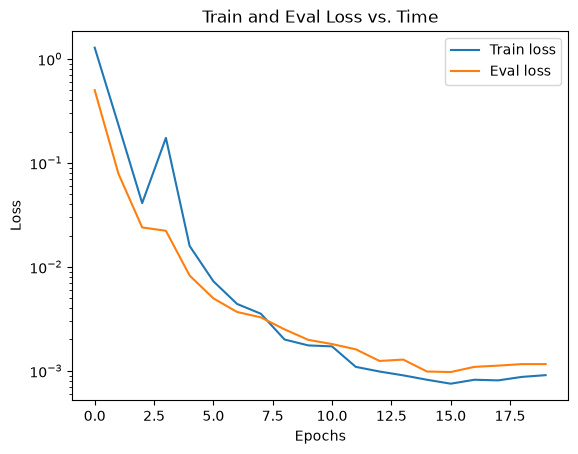

In [42]:
import matplotlib.pyplot as plt

epochs = np.arange(n_epochs)

plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, eval_losses, label="Eval loss")
plt.ylabel("Loss")
plt.yscale("log")
plt.xlabel("Epochs")
plt.title("Train and Eval Loss vs. Time")
plt.legend()
plt.show()